In [4]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
import unicodedata


In [5]:
df1=pd.read_csv("../data/terrasses-autorisations.csv", sep=";")
df2=pd.read_csv("../data/dans-ma-rue.csv", sep=";")

In [6]:
df2['adresse']=df2['adresse'].str.split(',').str[0]

In [7]:
df2['adresse']

0                    16 rue Victor Duruy
1             31 Boulevard Saint-Jacques
2                          2 Rue d'Orsel
3                    63 Quai de la Seine
4          8 Boulevard de Bonne Nouvelle
                       ...              
1474280                     21 Rue Titon
1474281            16 Avenue Léon Bollée
1474282           236 Boulevard Voltaire
1474283                    2 Rue Emeriau
1474284            199 Rue du Chevaleret
Name: adresse, Length: 1474285, dtype: object

In [8]:
df2['adresse']= df2['adresse'].str.upper()
df1['adresse']= df1['adresse'].str.upper()

In [9]:
df2['adresse']=df2['adresse'].str.strip()
df1['adresse']=df1['adresse'].str.strip()

# Retirer les accents

In [10]:
def strip_accents(s):
    if pd.isna(s):
        return s
    nfkd = unicodedata.normalize('NFKD', s)
    return ''.join(c for c in nfkd if not unicodedata.combining(c))

df1['adresse'] = df1['adresse'].apply(strip_accents)
df2['adresse'] = df2['adresse'].apply(strip_accents)

# Collapse des espaces multiples en un seul espace

In [11]:
df1['adresse'] = df1['adresse'].str.replace(r'\s+', ' ', regex=True)
df2['adresse'] = df2['adresse'].str.replace(r'\s+', ' ', regex=True)

# Re-passer upper + strip apres ces transformations, sur les deux (idempotent, juste pour securiser)

In [12]:
# Verifier les virgules multiples dans l'adresse ORIGINALE de dans-ma-rue 
# -> necessite de relire la colonne brute puisque df2['adresse'] a deja ete splitee

In [13]:
tmp = pd.read_csv("../data/dans-ma-rue.csv", sep=";", usecols=["adresse"])
print(tmp['adresse'].str.count(',').value_counts())

adresse
1    1474251
2         31
0          3
Name: count, dtype: int64


# Mesure du recouvrement apres nettoyage

In [14]:
adresses_terrasses = set(df1['adresse'].dropna().unique())
adresses_dmr = set(df2['adresse'].dropna().unique())
communes = adresses_terrasses & adresses_dmr

print(f"Adresses uniques terrasses    : {len(adresses_terrasses)}")
print(f"Adresses uniques dans-ma-rue  : {len(adresses_dmr)}")
print(f"Adresses communes             : {len(communes)}")
print(f"Taux de recouvrement (cote terrasses) : {len(communes)/len(adresses_terrasses):.1%}")

Adresses uniques terrasses    : 14862
Adresses uniques dans-ma-rue  : 152698
Adresses communes             : 12021
Taux de recouvrement (cote terrasses) : 80.9%


In [15]:
df1['adresse'].duplicated().sum()

np.int64(9344)

In [16]:
df2['adresse'].duplicated().sum()

np.int64(1321587)

In [17]:
df1['periode_installation'].unique()

<StringArray>
[                nan,     'Toute l'année', 'du 11/04 Au 10/10',
 'du 01/10 Au 31/03', 'du 01/04 Au 30/09', 'du 15/03 Au 15/09',
 'du 31/12 Au 30/12', 'du 10/03 Au 10/09', 'du 31/05 Au 30/11']
Length: 9, dtype: str

In [18]:
df1.groupby('adresse').size()

adresse
- 143 BOULEVARD LEFEBVRE    1
0 RUE DU MONT CENIS         1
01 RUE DOMREMY              1
1 ALLEE DARIUS MILHAUD      1
1 AVENUE D'ITALIE           2
                           ..
RUE DU PELICAN              1
RUE FERDINAND DUVAL         1
RUE SAINT DOMINIQUE         1
RUE SURCOUF                 1
SSSS                        1
Length: 14862, dtype: int64

In [19]:
tailles = df1.groupby('adresse').size()
# print((tailles > 1).sum())        # nombre d'adresses avec 2+ terrasses
# print(tailles.value_counts())     # repartition complete : combien d'adresses ont 1, 2, 3... 
print(tailles)

adresse
- 143 BOULEVARD LEFEBVRE    1
0 RUE DU MONT CENIS         1
01 RUE DOMREMY              1
1 ALLEE DARIUS MILHAUD      1
1 AVENUE D'ITALIE           2
                           ..
RUE DU PELICAN              1
RUE FERDINAND DUVAL         1
RUE SAINT DOMINIQUE         1
RUE SURCOUF                 1
SSSS                        1
Length: 14862, dtype: int64


In [20]:
# 1. Adresses avec une seule terrasse (attribution non ambigue)
tailles = df1.groupby('adresse').size()
adresses_uniques = tailles[tailles == 1].index

# 2. On filtre df1 sur ces adresses
df1_clean = df1[df1['adresse'].isin(adresses_uniques)]

# 3. Inner join avec df2
df_join = df1_clean.merge(df2, on='adresse', how='inner', suffixes=('_terrasse', '_signalement'))

print(df_join.shape)

(94785, 28)


In [21]:
df_join

,typologie,adresse,arrondissement_terrasse,nom_enseigne,nom_societe,siret,longueur,largeur,periode_installation,lien_affichette,...,conseilquartier,datedecl,anneedecl,moisdecl,prefixe,intervenant,id_dmr,geo_shape_signalement,geo_point_2d_signalement,mois_annee_decla
0,TERRASSE FERMÉE,79 AVENUE DE SEGUR,75015.0,FÉLIX RESTAURANT,NaN,8.193063e+13,12.12,2.0,NaN,https://eudonet-terrasses.apps.paris.fr/xrm/at...,...,CAMBRONNE - GARIBALDI,2025-01-17,2025,1,IOS application,DPE-STPP-DT,A2025A087574,"{""coordinates"": [2.305659300528242, 48.8473969...","48.847396998797045, 2.305659300528242",2025-01
1,TERRASSE FERMÉE,79 AVENUE DE SEGUR,75015.0,FÉLIX RESTAURANT,NaN,8.193063e+13,12.12,2.0,NaN,https://eudonet-terrasses.apps.paris.fr/xrm/at...,...,CAMBRONNE - GARIBALDI,2025-12-07,2025,12,Back Office,DPE-STPP-DT,B2025L034905,"{""coordinates"": [2.3059764429120357, 48.847391...","48.84739154061818, 2.3059764429120357",2025-12
2,TERRASSE FERMÉE,79 AVENUE DE SEGUR,75015.0,FÉLIX RESTAURANT,NaN,8.193063e+13,12.12,2.0,NaN,https://eudonet-terrasses.apps.paris.fr/xrm/at...,...,CAMBRONNE - GARIBALDI,2025-07-29,2025,7,IOS application,DPE-STPP-DT,A2025G158025,"{""coordinates"": [2.305866500111666, 48.8475569...","48.84755699895653, 2.305866500111666",2025-07
3,TERRASSE FERMÉE,79 AVENUE DE SEGUR,75015.0,FÉLIX RESTAURANT,NaN,8.193063e+13,12.12,2.0,NaN,https://eudonet-terrasses.apps.paris.fr/xrm/at...,...,CAMBRONNE - GARIBALDI,2026-04-09,2026,4,Android,DPMP-UEV,G2026D046423,"{""coordinates"": [2.3058523998415947, 48.847346...","48.84734699861689, 2.3058523998415947",2026-04
4,TERRASSE FERMÉE,79 AVENUE DE SEGUR,75015.0,FÉLIX RESTAURANT,NaN,8.193063e+13,12.12,2.0,NaN,https://eudonet-terrasses.apps.paris.fr/xrm/at...,...,CAMBRONNE - GARIBALDI,2025-01-17,2025,1,IOS application,DPE-STPP-DT,A2025A083234,"{""coordinates"": [2.3058953002415192, 48.847594...","48.84759499864925, 2.3058953002415192",2025-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94780,CONTRE TERRASSE ESTIVALE SUR STATIONNEMENT,46 AVENUE EMILE ZOLA,75015.0,LES DÉLICES D'ORIENT,NaN,4.021462e+13,10.00,1.7,NaN,NaN,...,EMERIAU - ZOLA,2025-11-24,2025,11,IOS application,DVD,A2025K118769,"{""coordinates"": [2.282710000207423, 48.8462029...","48.8462029989377, 2.282710000207423",2025-11
94781,CONTRE TERRASSE ESTIVALE SUR STATIONNEMENT,36 RUE D'AUTEUIL,75016.0,GINETTE,NaN,9.286980e+13,6.00,1.7,NaN,NaN,...,AUTEUIL NORD,2026-04-03,2026,4,Page DMR Paris.fr,DPMP-Divisions,S2026D014327,"{""coordinates"": [2.2660340000566834, 48.847693...","48.8476939991117, 2.2660340000566834",2026-04
94782,CONTRE TERRASSE ESTIVALE SUR STATIONNEMENT,36 RUE D'AUTEUIL,75016.0,GINETTE,NaN,9.286980e+13,6.00,1.7,NaN,NaN,...,AUTEUIL NORD,2026-03-16,2026,3,Page DMR Paris.fr,DPMP-Divisions,S2026C090245,"{""coordinates"": [2.2660340000566834, 48.847693...","48.8476939991117, 2.2660340000566834",2026-03
94783,TERRASSE ESTIVALE SUR TROTTOIR FACE À LA DEVAN...,117 AVENUE DE LA BOURDONNAIS,75007.0,HÔTEL LE CERCLE,NaN,4.340117e+13,6.00,2.6,NaN,NaN,...,GROS CAILLOU,2025-01-11,2025,1,Android,DPE-STPP-DT,G2025A051493,"{""coordinates"": [2.3047825996387297, 48.854773...","48.854773999264296, 2.3047825996387297",2025-01


In [22]:
# Tableau croisé : effectifs bruts
contingence = pd.crosstab(df_join['typologie'], df_join['type'])
print(contingence)

# Meme tableau mais en % par ligne, plus lisible pour comparer les typologies entre elles
print(pd.crosstab(df_join['typologie'], df_join['type'], normalize='index'))

# Test statistique
chi2, p, dof, expected = chi2_contingency(contingence)
print(f"p-value : {p}")

type                                                Activités commerciales et professionnelles  \
typologie                                                                                        
COMMERCE ACCESSOIRE                                                                          1   
CONTRE ETALAGE                                                                               0   
CONTRE TERRASSE ESTIVALE SUR PLACES ET TERRE-PLEIN                                          19   
CONTRE TERRASSE ESTIVALE SUR STATIONNEMENT                                                1256   
CONTRE TERRASSE ESTIVALE SUR TROTTOIR DÉSAXÉE P...                                           3   
CONTRE TERRASSE ESTIVALE SUR TROTTOIR FACE À LA...                                         188   
CONTRE TERRASSE SUR TROTTOIR                                                                22   
CONTRE TERRASSE SUR VOIE PIÉTONNE                                                           15   
CONTRE ÉTALAGE SUR P

In [23]:
# n = nombre total de signalements dans le tableau croise
n = contingence.sum().sum()

# r = nombre de typologies de terrasse differentes (lignes du tableau)
# c = nombre de types de signalement differents (colonnes du tableau)
r, c = contingence.shape

# formule du V de Cramer
cramers_v = (chi2 / (n * min(r - 1, c - 1))) ** 0.5

print(f"n (total signalements) : {n}")
print(f"r (typologies)         : {r}")
print(f"c (types signalement)  : {c}")
print(f"V de Cramer            : {cramers_v:.3f}")

n (total signalements) : 94774
r (typologies)         : 29
c (types signalement)  : 10
V de Cramer            : 0.075


In [24]:
adresses_terrasses = set(df1['adresse'].dropna().unique())
df2['a_une_terrasse'] = df2['adresse'].isin(adresses_terrasses)

contingence_h1 = pd.crosstab(df2['a_une_terrasse'], df2['type'])
print(contingence_h1)

chi2_h1, p_h1, dof_h1, expected_h1 = chi2_contingency(contingence_h1)

n_h1 = contingence_h1.sum().sum()
r_h1, c_h1 = contingence_h1.shape
cramers_v_h1 = (chi2_h1 / (n_h1 * min(r_h1 - 1, c_h1 - 1))) ** 0.5

print(f"p-value H1     : {p_h1}")
print(f"V de Cramer H1 : {cramers_v_h1:.3f}")

type            Activités commerciales et professionnelles  \
a_une_terrasse                                               
False                                                17596   
True                                                 13316   

type            Arbres, végétaux et animaux  \
a_une_terrasse                                
False                                 16335   
True                                   2322   

type            Autos, motos, vélos, trottinettes...  Dégradation du sol  \
a_une_terrasse                                                             
False                                          76322                   1   
True                                           10180                   0   

type             Eau  Graffitis, tags, affiches et autocollants  \
a_une_terrasse                                                    
False           7048                                     297183   
True             948                                    

In [25]:

print("NaN dans typologie :", df1['typologie'].isna().sum())
print("NaN dans type (df2) :", df2['type'].isna().sum())
print("NaN dans adresse df1 :", df1['adresse'].isna().sum())
print("NaN dans adresse df2 :", df2['adresse'].isna().sum())


NaN dans typologie : 10
NaN dans type (df2) : 0
NaN dans adresse df1 : 8
NaN dans adresse df2 : 0


In [26]:
print("Lignes dupliquees df1 :", df1.duplicated().sum())
print("Lignes dupliquees df2 :", df2.duplicated().sum())

Lignes dupliquees df1 : 0
Lignes dupliquees df2 : 0


In [27]:
incoherent = df_join['arrondissement_terrasse'] != df_join['arrondissement_signalement']
print(f"Lignes incoherentes : {incoherent.sum()} sur {len(df_join)} ({incoherent.mean():.2%})")

Lignes incoherentes : 94785 sur 94785 (100.00%)


In [28]:
print(df1['arrondissement'].dtype, df2['arrondissement'].dtype)
print(df_join[['arrondissement_terrasse', 'arrondissement_signalement']].dtypes)
print(df_join[['arrondissement_terrasse', 'arrondissement_signalement']].head(10))


float64 int64
arrondissement_terrasse       float64
arrondissement_signalement      int64
dtype: object
   arrondissement_terrasse  arrondissement_signalement
0                  75015.0                          15
1                  75015.0                          15
2                  75015.0                          15
3                  75015.0                          15
4                  75015.0                          15
5                  75015.0                          15
6                  75015.0                          15
7                  75015.0                          15
8                  75015.0                          15
9                  75015.0                          15


In [29]:
df_join['arrondissement_terrasse_num'] = (df_join['arrondissement_terrasse'] % 100).astype('Int64')

incoherent2 = df_join['arrondissement_terrasse_num'] != df_join['arrondissement_signalement']
print(f"Lignes incoherentes (apres correction) : {incoherent2.sum()} sur {len(df_join)} ({incoherent2.mean():.2%})")

Lignes incoherentes (apres correction) : 3202 sur 94785 (3.51%)


# H1-bis : densite de terrasses par arrondissement vs signalements commerciaux

Hypothese : les arrondissements avec une densite de terrasses plus elevee
presentent-ils aussi une densite plus elevee de signalements "Activites
commerciales et professionnelles" ?

Note : association ecologique au niveau arrondissement (agregats), pas un
effet demontre au niveau d'une terrasse individuelle -- a garder en tete
dans l'interpretation finale.

Etape 1 : verifier l'unite de la colonne `surface` de quartier_paris et la
coherence des codes d'arrondissement (`c_ar`) avant de calculer quoi que
ce soit.

In [30]:
import geopandas as gpd

quartiers = gpd.read_file("../data/quartier_paris.geojson")

# Verifier l'unite de surface et la coherence des codes arrondissement
print(quartiers[['c_ar', 'surface']].describe())
print(sorted(quartiers['c_ar'].unique()))

            c_ar       surface
count  80.000000  8.000000e+01
mean   10.500000  1.317160e+06
std     5.802662  1.332116e+06
min     1.000000  1.880122e+05
25%     5.750000  4.971428e+05
50%    10.500000  9.282372e+05
75%    15.250000  1.468378e+06
max    20.000000  7.205014e+06
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20)]


Confirme : `surface` est en m2 (moyenne x 80 quartiers ~= 105 km2, ca correspond
a la superficie totale de Paris) et `c_ar` va bien de 1 a 20, meme codage que
`arrondissement % 100` cote terrasses. On peut calculer les agregats.

In [31]:
# Etape 1 : nb de terrasses par arrondissement (df1 complet, pas df1_clean)
terrasses_par_arr = df1.groupby((df1['arrondissement'] % 100).astype('Int64')).size()
terrasses_par_arr.name = 'nb_terrasses'

# Etape 2 : nb de signalements et nb de signalements "commerciaux" par arrondissement
signalements_par_arr = df2.groupby('arrondissement').size()
signalements_par_arr.name = 'nb_signalements'

commerciaux_par_arr = (
    df2[df2['type'] == 'Activités commerciales et professionnelles']
    .groupby('arrondissement')
    .size()
)
commerciaux_par_arr.name = 'nb_commerciaux'

pct_commercial_par_arr = (commerciaux_par_arr / signalements_par_arr * 100)
pct_commercial_par_arr.name = 'pct_commercial'

print(terrasses_par_arr)

arrondissement
1      847
2      672
3      568
4      890
5     1275
6      761
7      696
8     1180
9     1351
10    1682
11    1554
12    1385
13    1063
14    1296
15    1713
16    1287
17    1546
18    1509
19     904
20    1180
Name: nb_terrasses, dtype: int64


In [32]:
# Etape 3 : surface par arrondissement, convertie en km2
surface_par_arr = quartiers.groupby('c_ar')['surface'].sum()
surface_par_arr.index = surface_par_arr.index.astype('Int64')

surface_par_arr_km2 = surface_par_arr / 1_000_000
surface_par_arr_km2.name = 'surface_arr_km2'

print(surface_par_arr_km2)

c_ar
1      1.824613
2      0.991154
3      1.170883
4      1.600586
5      2.539374
6      2.153096
7      4.090057
8      3.880037
9      2.178303
10     2.891739
11     3.665442
12    16.314783
13     7.149311
14     5.614878
15     8.494994
16    16.372540
17     5.668834
18     5.996051
19     6.792651
20     5.983446
Name: surface_arr_km2, dtype: float64


In [33]:
# Etape 4 : assembler le tableau final et calculer les 2 densites
resume_zones = pd.concat([
    terrasses_par_arr,
    signalements_par_arr,
    commerciaux_par_arr,
    pct_commercial_par_arr,
    surface_par_arr_km2
], axis=1)

print("Valeurs manquantes avant filtrage :")
print(resume_zones.isnull().sum())

# Des codes d'arrondissement invalides (0, 44, 82... -- Paris n'a que 1 a 20) trainent
# dans dans-ma-rue, en quantite negligeable (~100 signalements sur 1.47M). On les
# retire plutot que de laisser des NaN casser les correlations.
resume_zones = resume_zones.dropna()
print(f"\n{len(resume_zones)} arrondissements valides conserves (sur 20 attendus)")

resume_zones['densite_terrasses_km2'] = resume_zones['nb_terrasses'] / resume_zones['surface_arr_km2']
resume_zones['taux_commerciaux_km2'] = resume_zones['nb_commerciaux'] / resume_zones['surface_arr_km2']

print(resume_zones)

Valeurs manquantes avant filtrage :
nb_terrasses       3
nb_signalements    0
nb_commerciaux     2
pct_commercial     2
surface_arr_km2    3
dtype: int64

20 arrondissements valides conserves (sur 20 attendus)
    nb_terrasses  nb_signalements  nb_commerciaux  pct_commercial  \
1          847.0            23680          1277.0        5.392736   
2          672.0            24986          1610.0        6.443608   
3          568.0            52893          1537.0        2.905867   
4          890.0            46020          1212.0        2.633638   
5         1275.0            32249           615.0        1.907036   
6          761.0            21623          1021.0        4.721824   
7          696.0            22705           495.0        2.180137   
8         1180.0            37317           768.0        2.058043   
9         1351.0            61152          2770.0        4.529696   
10        1682.0           105243          1918.0        1.822449   
11        1554.0           1121

In [34]:
# Etape 5 : correlations -- 2 comparaisons seulement (pas toutes les combinaisons possibles)
from scipy.stats import spearmanr, pearsonr

def correlations(x, y):
    rho, p_rho = spearmanr(x, y)
    r, p_r = pearsonr(x, y)
    return rho, p_rho, r, p_r

resultats = pd.DataFrame([
    ['densite_terrasses_km2 vs taux_commerciaux_km2 (principal)',
     *correlations(resume_zones['densite_terrasses_km2'], resume_zones['taux_commerciaux_km2'])],
    ['nb_terrasses vs pct_commercial (controle)',
     *correlations(resume_zones['nb_terrasses'], resume_zones['pct_commercial'])],
], columns=['comparaison', 'spearman_rho', 'spearman_p', 'pearson_r', 'pearson_p'])

print(resultats)

                                         comparaison  spearman_rho  \
0  densite_terrasses_km2 vs taux_commerciaux_km2 ...      0.888722   
1          nb_terrasses vs pct_commercial (controle)     -0.332456   

     spearman_p  pearson_r  pearson_p  
0  1.648527e-07   0.807617   0.000017  
1  1.520952e-01  -0.372376   0.105910  


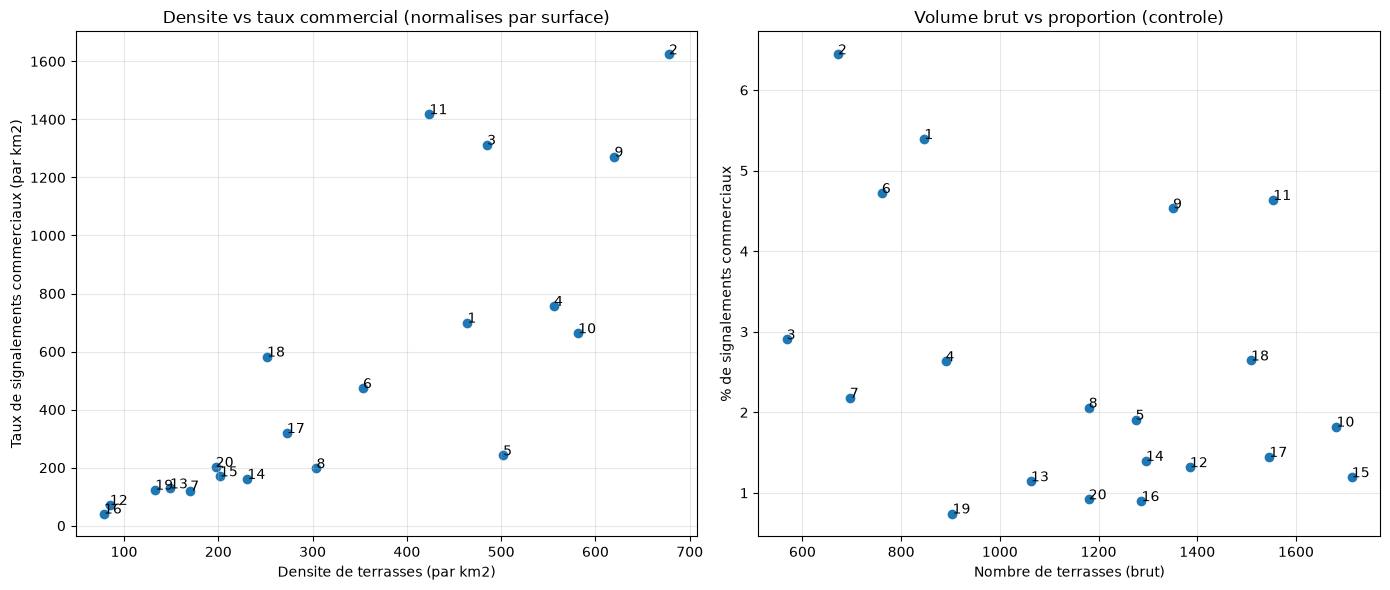

In [35]:
# Etape 6 : 2 graphiques separes (ne pas melanger densite et volume brut sur le meme axe)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(resume_zones['densite_terrasses_km2'], resume_zones['taux_commerciaux_km2'])
for arr, row in resume_zones.iterrows():
    axes[0].annotate(str(arr), (row['densite_terrasses_km2'], row['taux_commerciaux_km2']))
axes[0].set_xlabel("Densite de terrasses (par km2)")
axes[0].set_ylabel("Taux de signalements commerciaux (par km2)")
axes[0].set_title("Densite vs taux commercial (normalises par surface)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(resume_zones['nb_terrasses'], resume_zones['pct_commercial'])
for arr, row in resume_zones.iterrows():
    axes[1].annotate(str(arr), (row['nb_terrasses'], row['pct_commercial']))
axes[1].set_xlabel("Nombre de terrasses (brut)")
axes[1].set_ylabel("% de signalements commerciaux")
axes[1].set_title("Volume brut vs proportion (controle)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correction : corrélation fallacieuse des ratios (Pearson, 1897)

`densite_terrasses_km2` et `taux_commerciaux_km2` divisent toutes les deux par
`surface_arr_km2`, qui varie d'un facteur ~17 selon l'arrondissement (0.99 a
16.4 km2, a cause du Bois de Vincennes/Boulogne dans le 12e/16e). Un
denominateur partage qui varie autant peut a lui seul creer une correlation
entre deux ratios, meme si les numerateurs sont independants. Le "controle"
precedent (nb_terrasses vs pct_commercial) changeait X ET Y en meme temps,
ce n'etait pas un vrai controle.

Deux verifications qui ne partagent pas ce probleme :
1. `commerciaux_par_terrasse` (nb_commerciaux / nb_terrasses) vs
   `densite_terrasses_km2` -- plus de `surface` des deux cotes.
2. Regression de `nb_commerciaux` sur `nb_terrasses` EN CONTROLANT `surface`
   -- si le coefficient de nb_terrasses reste significatif une fois la
   surface neutralisee, c'est un vrai signal.

In [36]:
# Verification 1 : ratio sans denominateur partage
resume_zones['commerciaux_par_terrasse'] = resume_zones['nb_commerciaux'] / resume_zones['nb_terrasses']

rho_v1, p_v1 = spearmanr(resume_zones['densite_terrasses_km2'], resume_zones['commerciaux_par_terrasse'])
r_v1, pr_v1 = pearsonr(resume_zones['densite_terrasses_km2'], resume_zones['commerciaux_par_terrasse'])

print(f"Spearman : {rho_v1:.3f} (p={p_v1:.4f})")
print(f"Pearson  : {r_v1:.3f} (p={pr_v1:.4f})")

Spearman : 0.544 (p=0.0131)
Pearson  : 0.528 (p=0.0168)


In [37]:
# Verification 2 : regression avec surface en covariable
import statsmodels.api as sm

X = resume_zones[['nb_terrasses', 'surface_arr_km2']]
X = sm.add_constant(X)
y = resume_zones['nb_commerciaux']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         nb_commerciaux   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     4.239
Date:                Mon, 24 Aug 2026   Prob (F-statistic):             0.0321
Time:                        20:29:32   Log-Likelihood:                -164.38
No. Observations:                  20   AIC:                             334.8
Df Residuals:                      17   BIC:                             337.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -110.5085    773.956     

In [38]:
# Verification 3 : nb_commerciaux est un comptage, pas une variable continue --
# l'OLS suppose implicitement le contraire (residus non-normaux deja constates).
# Regression binomiale negative, plus adaptee a des donnees de comptage.
model_nb = sm.GLM(y, X, family=sm.families.NegativeBinomial()).fit()
print(model_nb.summary())

# Verification 4 : multicollinearite reelle entre les 2 predicteurs (pas juste
# une difference d'echelle) -- le condition number eleve de l'OLS le suggerait.
print("\nCorrelation entre les 2 predicteurs :")
print(resume_zones[['nb_terrasses', 'surface_arr_km2']].corr())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         nb_commerciaux   No. Observations:                   20
Model:                            GLM   Df Residuals:                       17
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -165.26
Date:                Mon, 24 Aug 2026   Deviance:                       4.0667
Time:                        20:29:32   Pearson chi2:                     4.05
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1485
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               6.3135      0.795     

c:\Users\ayham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [39]:
# Correction : le GLM precedent utilisait alpha=1.0 par defaut (non estime,
# voir le warning). Version qui estime vraiment le parametre de dispersion
# par maximum de vraisemblance -- la seule fiable pour conclure.
model_nb_mle = sm.NegativeBinomial(y, X).fit()
print(model_nb_mle.summary())

         Current function value: 7.800880
         Iterations: 12
         Function evaluations: 50
         Gradient evaluations: 38
                     NegativeBinomial Regression Results                      
Dep. Variable:         nb_commerciaux   No. Observations:                   20
Model:               NegativeBinomial   Df Residuals:                       17
Method:                           MLE   Df Model:                            2
Date:                Mon, 24 Aug 2026   Pseudo R-squ.:                 0.03749
Time:                        20:33:24   Log-Likelihood:                -156.02
converged:                      False   LL-Null:                       -162.09
Covariance Type:            nonrobust   LLR p-value:                  0.002296
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               6.3133      0.338     18.694      0.000       

c:\Users\ayham\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\optimize\_optimize.py:1330: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
c:\Users\ayham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [40]:
# Dernier essai : plus d'iterations pour aider la convergence.
# Si ca ne converge toujours pas, c'est une vraie limite (n=20 trop petit
# pour ce modele a 4 parametres) a documenter, pas un bug a poursuivre.
model_nb_mle2 = sm.NegativeBinomial(y, X).fit(maxiter=1000, disp=False)
print(model_nb_mle2.summary())
print("\nConverged:", model_nb_mle2.mle_retvals.get('converged'))

                     NegativeBinomial Regression Results                      
Dep. Variable:         nb_commerciaux   No. Observations:                   20
Model:               NegativeBinomial   Df Residuals:                       17
Method:                           MLE   Df Model:                            2
Date:                Mon, 24 Aug 2026   Pseudo R-squ.:                 0.03749
Time:                        20:34:58   Log-Likelihood:                -156.02
converged:                      False   LL-Null:                       -162.09
Covariance Type:            nonrobust   LLR p-value:                  0.002296
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               6.3133      0.338     18.694      0.000       5.651       6.975
nb_terrasses        0.0011      0.000      3.740      0.000       0.001       0.002
surface_arr_km2    -0.0708      

c:\Users\ayham\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Conclusion H1-bis (fermee)

Apres correction d'un artefact initial de correlation fallacieuse par
denominateur partage (r=0.889 -> non fiable, cause par le partage de
`surface` dans les deux ratios compares), l'analyse converge vers :

**Une association positive moderee et statistiquement significative entre
le nombre/la densite de terrasses et le volume de signalements lies aux
activites commerciales, au niveau des 20 arrondissements parisiens.**

- Ratio sans denominateur partage (densite_terrasses_km2 vs
  commerciaux_par_terrasse) : Spearman rho=0.544 (p=0.013), Pearson
  r=0.528 (p=0.017)
- OLS (nb_commerciaux ~ nb_terrasses + surface) : coefficient
  nb_terrasses significatif (p=0.013) meme en controlant la surface
- Multicollinearite entre nb_terrasses et surface : faible (r=0.38),
  pas un probleme reel
- Tentative de regression binomiale negative (plus adaptee a une
  variable de comptage) : non convergee malgre plusieurs essais --
  limite de taille d'echantillon (n=20 trop petit pour ce modele a 4
  parametres), pas un resultat contradictoire

**A rappeler explicitement dans toute presentation** : association
ecologique mesuree au niveau des arrondissements (agregats), pas un
effet demontre au niveau d'une terrasse individuelle ni une relation
causale.

**Recommandation finale (revisee, plus prudente que la version initiale)** :
les donnees soutiennent de cibler les inspections vers les zones a forte
densite de terrasses plutot qu'une repartition uniforme, mais l'effet
mesure est modere (pas spectaculaire) et repose sur seulement 20 unites
geographiques -- a formuler avec cette nuance a l'oral.